# ***Data Collection***

In [ ]:
# %%capture
# !pip install synapseclient


In [ ]:

# import synapseclient
# import synapseutils
# import os

# class downloader:
#     def __init__(self, token, folder_path):
#         self.token = token
#         self.folder_path = folder_path

#     def download(self):
#         syn = synapseclient.Synapse()
#         syn.login(authToken=self.token)

#         # Ensure the folder exists
#         os.makedirs(self.folder_path, exist_ok=True)

#         # Download to the specified folder
#         files = synapseutils.syncFromSynapse(syn, 'syn51156910', path=self.folder_path)
#         print(f"Download complete. Files saved to: {self.folder_path}")

# # Example usage
# token = input("Enter your token: ")
# target_folder = "/content/drive/MyDrive/Brain_Project/Data/BraTS2023"  # Change this to your desired folder
# downloader = downloader(token, target_folder)
# downloader.download()



In [1]:
%%capture
!pip install torchio
# Core scientific and visualization libraries
!pip install matplotlib numpy nibabel

# PyTorch (Colab usually has it preinstalled, but you can force install if needed)
!pip install torch

# TorchIO for medical imaging transforms and patch sampling
!pip install torchio
!pip install torchsummary


In [2]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset , dataloader
import torchio as tio
from torchio import Queue
from torchio import SubjectsDataset, UniformSampler
from torch.nn import functional as F
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torchsummary import summary
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from torch.utils.checkpoint import checkpoint

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # data_loc = "/content/drive/MyDrive/Brain_Project/Data"
#training_data_loc_unzipped = "/content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
# !unzip /content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip -d /content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData

# ***Data_Visualization***

In [ ]:
# class Visulaizer:
#     def __init__(self, data_loc,
#                  figsize = (10,10) ,    #Tuple figure size
#                  rows = 3 , cols = 3 ,  #number of rows and cols in fig
#                  visual_class = 0 , #visual class among  [self.t1 --> 0 , self.t1ce  --> 1 , self.t2   --> 2, self.flair  --> 3 , self.seg   --> 4]
#                  from_slice = 80 ,  #starting index of slices among 155
#                  to_slice = 89 ,  #ending index of slices among 155   but keep in mind that to_slic-from_slice should be equal to rows x cols
#                  cmap = 'grey' ,
#                  random_choice = False ,
#                  index = 0
#                  ):


#         self.data_loc = data_loc
#         self.figsize = figsize
#         self.rows = rows
#         self.cols = cols
#         self.visual_class = visual_class
#         self.from_slice = from_slice
#         self.to_slice = to_slice
#         self.cmap = cmap
#         self.random_choice = random_choice
#         self.index = index


#         #Importing pakages
#         try:
#           import os
#           import random
#           import matplotlib.pyplot as plt
#           import numpy as np
#           import nibabel as nib
#         except ImportError:
#           print("Please install matplotlib and numpy")
#         self.data = self.get_data(self.data_loc)


#     def get_data(self , data_loc):
#       if self.random_choice:
#         self.patient =  random.choice(os.listdir(self.data_loc))
#         print(f"Patient Choosen : {self.patient}")
#       else:
#         self.patient = os.listdir(self.data_loc)[self.index]
#         print(f"Patient Choosen : {self.patient} at index : {self.index}")
#       self.patient_path = os.path.join(self.data_loc , self.patient)
#       self.patient_files = os.listdir(self.patient_path)

#       self.t1n_path = os.path.join(self.patient_path , [f for f in self.patient_files if f.endswith('-t1n.nii.gz')][0]) # This is T1
#       self.t1c_path = os.path.join(self.patient_path, [f for f in self.patient_files if f.endswith('-t1c.nii.gz')][0]) # This is T1ce
#       self.t2w_path =  os.path.join(self.patient_path, [f for f in self.patient_files if f.endswith('-t2w.nii.gz')][0]) # This is T2
#       self.t2f_path = os.path.join(self.patient_path, [f for f in self.patient_files if f.endswith('-t2f.nii.gz')][0]) # This is FLAIR
#       self.seg_path = os.path.join(self.patient_path, [f for f in self.patient_files if f.endswith('-seg.nii.gz')][0]) # This is the Segmentation mask

#       #fetching data from files
#       # Load the files
#       self.t1 = nib.load(self.t1n_path).get_fdata()    # Loading 't1n' as T1
#       self.t1ce = nib.load(self.t1c_path).get_fdata()  # Loading 't1c' as T1ce
#       self.t2 = nib.load(self.t2w_path).get_fdata()    # Loading 't2w' as T2
#       self.flair = nib.load(self.t2f_path).get_fdata() # Loading 't2f' as FLAIR
#       self.seg = nib.load(self.seg_path).get_fdata()


#       self.patient_data = (self.t1 , self.t1ce , self.t2 , self.flair , self.seg)
#       return self.patient_data

#     def get_visuals(self , patinet_data):
#       self.t1 , self.t1ce , self.t2 , self.flair , self.seg = patinet_data

#       self.fig , axes = plt.subplots(self.cols,self.rows,figsize=self.figsize)
#       axes = axes.ravel()
#       li  = [self.t1 , self.t1ce , self.t2 , self.flair , self.seg]
#       for i in range(self.from_slice , self.to_slice):
#         ax = axes[i-self.from_slice]
#         im = ax.imshow(li[self.visual_class][:,:,i] , cmap=self.cmap ,interpolation='nearest' )
#         ax.set_title(f"T1 {i}" , )
#         ax.axis('off')
#         self.fig.colorbar(im , ax=ax, shrink = 0.5)
#       plt.show()

#     def save_visuals(self , save_path):
#       self.fig.savefig(save_path , dpi=600, bbox_inches='tight')
#       plt.close()
#       print(f"Figure saved to {save_path}")

#     def plot_hist(self , patinet_data):
#       self.t1 , self.t1ce , self.t2 , self.flair , self.seg = patinet_data
#       self.fig2 , axes = plt.subplots(2,3,figsize = (10,10))
#       axes = axes.ravel()

#       t1 = self.t1.reshape(-1)
#       t1ce = self.t1ce.reshape(-1)
#       t2 = self.t2.reshape(-1)
#       flair = self.flair.reshape(-1)
#       seg = self.seg.reshape(-1)
#       li = [t1 , t1ce , t2 , flair , seg]

#       for i in range(5):
#         ax = axes[i]
#         ax.hist(li[i] , bins=30 , color='blue', edgecolor='black', alpha=0.7)
#         ax.set_title(i)
#       plt.show()

#     def get_shape(self  , patinet_data):
#       self.t1 , self.t1ce , self.t2 , self.flair , self.seg = patinet_data
#       return([self.t1.shape , self.t1ce.shape , self.t2.shape , self.flair.shape , self.seg.shape])

# # obj = Visulaizer("/content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData" , visual_class=3)
# # obj.get_visuals(obj.data)
# # obj.plot_hist(obj.data)
# #   # obj.save_visuals(f"/content/{i}.png")
# # # Shape = obj.get_shape(obj.data)
# # # print(Shape)

In [4]:
# Masking
main_path = "/content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
# sub_dir = os.listdir(main_path)
# for x , subs in enumerate(sub_dir):
#   paths = os.path.join(main_path , subs)
#   print(f"Proccessing Patient : {x+1}")
#   content = os.listdir(paths)
#   file1 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t1n.nii.gz')][0])).get_fdata()
#   file2 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t1c.nii.gz')][0])).get_fdata()
#   file3 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t2w.nii.gz')][0])).get_fdata()
#   file4 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t2f.nii.gz')][0])).get_fdata()
#   mask = ((file1 != 0) | (file2 != 0) | (file3 != 0) | (file4 != 0)).astype(np.int8) #np.zeros((240, 240, 155)).astype(np.int8)

#   # for i in range(240):
#   #   for j in range(240):
#   #     for k in range(155):
#   #       mask[i,j,k] = 1 if (nib.load(file1).get_fdata()[i,j,k] != 0 or nib.load(file2).get_fdata()[i,j,k] != 0 or nib.load(file3).get_fdata()[i,j,k] != 0 or nib.load(file4).get_fdata()[i,j,k] != 0) else 0
#   np.save(f"{paths}/mask.npy" , mask)
#   print(f"Patient : {x+1} Done")
#   print(f"Saved Mask for Patient : {x+1} at : {paths}/mask.npy")



# ***Features and Target Preproccesing***

In [ ]:
# def normalize_volume(volume, mask):
#     brain_voxels = volume[mask == 1]
#     lower, upper = np.percentile(brain_voxels, [1, 99])
#     clipped = np.clip(brain_voxels, lower, upper)
#     mean = clipped.mean()
#     std = clipped.std()
#     normalized = (np.clip(volume, lower, upper) - mean) / std
#     return normalized

# def prepare_Feature(Path):
#   print("==================Starting Preprocessing==================")
#   sub_dir = os.listdir(main_path)
#   for x , subs in enumerate(sub_dir):
#     paths = os.path.join(main_path , subs)
#     print(f"Proccessing Patient : {x+1}")
#     content = os.listdir(paths)
#     if "normalized_arr.pt" not in content:
#       # file1 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t1n.nii.gz')][0])).get_fdata()
#       # file2 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t1c.nii.gz')][0])).get_fdata()
#       # file3 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t2w.nii.gz')][0])).get_fdata()
#       # file4 = nib.load(os.path.join(paths , [f for f in content if f.endswith('-t2f.nii.gz')][0])).get_fdata()
#       # mask = np.load(f"{paths}/mask.npy")
#       # print("\n")
#       # print(f"Files Loaded Successfully for Patient : {x+1}")
#       # print("\n")

#       # file1 = normalize_volume(file1, mask)
#       # file2 = normalize_volume(file2, mask)
#       # file3 = normalize_volume(file3, mask)
#       # file4 = normalize_volume(file4, mask)

#       normalized_arr = np.load(f"{paths}/normalized_arr.npy")
#       tensor = torch.from_numpy(normalized_arr).to(torch.float32)
#       print(tensor.shape)
#       print("\n")
#       print("======================================================")
#       torch.save(tensor , f"{paths}/normalized_arr.pt")
#       print(f"Saved Normalized Array for Patient : {x+1} at : {paths}/normalized_arr.pt")
#       print("\n")


#       normalized_arr_path = f"{paths}/normalized_arr.npy"
#       if os.path.exists(normalized_arr_path):
#         os.remove(normalized_arr_path)
#       else:
#         print(f"The file {normalized_arr_path} does not exist.")
#       print("======================================================")

#     else:
#       print("======================================================")
#       print(f"Already Done for Patient : {x+1}")
#       print("\n")
#       print("======================================================")
# prepare_Feature(main_path)

In [ ]:
# def verify_labels(label_volume):
#     unique_vals = np.unique(label_volume)
#     print(unique_vals)

# def prepare_Feature(Path):
#   print("==================Starting Preprocessing==================")
#   sub_dir = os.listdir(main_path)
#   for x , subs in enumerate(sub_dir):
#     paths = os.path.join(main_path , subs)
#     print(f"Proccessing Patient : {x+1}")
#     content = os.listdir(paths)
#     fil = nib.load(os.path.join(paths , [f for f in content if f.endswith('-seg.nii.gz')][0])).get_fdata()
#     verify_labels(fil)
#     tensor = torch.from_numpy(fil).to(torch.float32)
#     print(tensor.shape)
#     print("\n")
#     print("======================================================")
#     torch.save(tensor , f"{paths}/labels.pt")
#     print(f"Saved Labels for Patient : {x+1} at : {paths}/labels.pt")
#     print("\n")
#     print("======================================================")


#       # mask = np.load(f"{paths}/mask.npy")
#       # print("\n")
#       # print(f"Files Loaded Successfully for Patient : {x+1}")
#       # print("\n")

#       # file1 = normalize_volume(file1, mask)
#       # file2 = normalize_volume(file2, mask)
#       # file3 = normalize_volume(file3, mask)
#       # file4 = normalize_volume(file4, mask)

#       # normalized_arr = np.stack([file1, file2, file3, file4], axis=0)  # Shape: (4, 240, 240, 155)

#       # print(f"Shape of Preproccessed array :  {normalized_arr.shape}")


# np.set_printoptions(threshold=np.inf)  # Show entire array
# prepare_Feature(main_path)

In [ ]:
# import os
# from tqdm import tqdm

# def remove_wrong_files(main_path):
#     # Patterns of files to delete
#     wrong_files = [f"modality_{i}.nii.gz" for i in range(4)] + ["label.nii.gz"]

#     patient_folders = [f for f in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, f))]

#     for patient in tqdm(patient_folders, desc="Removing wrong files"):
#         patient_dir = os.path.join(main_path, patient)
#         for file_name in wrong_files:
#             file_path = os.path.join(patient_dir, file_name)
#             if os.path.exists(file_path):
#                 os.remove(file_path)
#                 print(f"Deleted: {file_path}")

# # Example usage
# main_path = "/content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
# remove_wrong_files(main_path)


In [ ]:
# import os
# import torch
# import nibabel as nib
# import numpy as np
# from tqdm import tqdm

# def convert_pt_to_nii(patient_dir):
#     features_path = os.path.join(patient_dir, "normalized_arr.pt")
#     labels_path = os.path.join(patient_dir, "labels.pt")

#     if not os.path.exists(features_path) or not os.path.exists(labels_path):
#         print(f"Skipping {patient_dir} — missing .pt files")
#         return

#     # Load tensors
#     features = torch.load(features_path)  # Expected: [4, 240, 240, 155]
#     labels = torch.load(labels_path)      # Expected: [240, 240, 155] or [1, ...]

#     # Shape check
#     if features.shape != (4, 240, 240, 155):
#         raise ValueError(f"Unexpected features shape {features.shape} in {patient_dir}")

#     # Add channel dim to labels if missing
#     if labels.ndim == 3:
#         labels = labels.unsqueeze(0)  # [1, 240, 240, 155]

#     # Convert to numpy
#     features_np = features.numpy()
#     labels_np = labels.numpy()

#     # Save directly in [C, X, Y, Z] format
#     nib.save(nib.Nifti1Image(features_np, affine=np.eye(4)),
#              os.path.join(patient_dir, "features.nii.gz"))
#     nib.save(nib.Nifti1Image(labels_np, affine=np.eye(4)),
#              os.path.join(patient_dir, "labels.nii.gz"))

# def batch_convert_all(main_path):
#     patient_folders = [f for f in os.listdir(main_path)
#                        if os.path.isdir(os.path.join(main_path, f))]
#     for patient in tqdm(patient_folders, desc="Converting .pt → .nii.gz"):
#         convert_pt_to_nii(os.path.join(main_path, patient))

# # Example usage
# main_path = "/content/drive/MyDrive/Brain_Project/Data/BraTS2023/Data/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

# batch_convert_all(main_path)


In [ ]:
# import nibabel as nib
# import numpy as np
# import os

# def fix_channels(patient_dir):
#     for fname in ["features.nii.gz", "labels.nii.gz"]:
#         path = os.path.join(patient_dir, fname)
#         img = nib.load(path)
#         data = img.get_fdata()

#         # If channels are first, move them to last
#         if data.shape[0] in (1, 4):
#             data = np.moveaxis(data, 0, -1)

#         nib.save(nib.Nifti1Image(data, img.affine), path)

# # Example: fix all patients
# for patient in patients:
#     fix_channels(os.path.join(main_path, patient))


In [5]:
def sanitize_targets(labels, num_classes=4, ignore_index=255):
    # labels: (N, 1, D,H,W) or (N, C, D,H,W)
    if labels.dim() == 5 and labels.size(1) > 1:
        # looks like one-hot; convert to indices
        labels = labels.argmax(dim=1, keepdim=True)
    elif labels.dim() == 5 and labels.size(1) == 1:
        pass
    elif labels.dim() == 4:
        labels = labels.unsqueeze(1)
    else:
        raise ValueError(f"Unexpected label shape: {labels.shape}")

    labels = labels.clone()

    # if you historically had a stray '4' meaning class 3:
    labels[labels == 4] = 3

    # enforce integers and valid range (or ignore)
    labels = labels.long()
    bad = (labels < 0) | (labels >= num_classes)
    labels[bad] = ignore_index

    # Final quick check
    uniq = torch.unique(labels)
    allowed = set(list(range(num_classes)) + [ignore_index])
    assert all(int(x) in allowed for x in uniq.cpu().tolist()), f"Bad labels: {uniq.tolist()}"
    return labels


In [6]:
import os
import torchio as tio

class MRI_Dataset(tio.SubjectsDataset):
    def __init__(self, patient_list, parent_path, transform=None):
        self.p_path = parent_path
        self.transform = transform
        self.patients = patient_list
        super().__init__(self.get_subjects_list(), transform=self.transform)

    def get_subjects_list(self):
        subjects_list = []
        for patient in self.patients:
            features = os.path.join(self.p_path, patient, "features.nii.gz")
            labels   = os.path.join(self.p_path, patient, "labels.nii.gz")
            subject = tio.Subject(
                image=tio.ScalarImage(features),
                label=tio.LabelMap(labels)  # discrete labels
            )
            subjects_list.append(subject)
        return subjects_list


In [7]:
from torchio import Queue, UniformSampler
from sklearn.model_selection import train_test_split
import os

# Split patients
all_items = os.listdir(main_path)
patients = [item for item in all_items if os.path.isdir(os.path.join(main_path, item))]
train_subjects, test_subjects = train_test_split(patients, test_size=0.05, random_state=42)

# Augmentations
transforms = tio.Compose([
    tio.RandomFlip(),
    tio.RandomAffine(degrees=10),
    tio.RandomNoise()
])

# Patch sampler
patch_size =(64, 64, 64)
sampler = UniformSampler(patch_size=patch_size)

# Datasets
# train_dataset = MRI_Dataset(train_subjects, main_path, transform=transforms)
test_dataset  = MRI_Dataset(test_subjects, main_path)

# Queues
# train_queue = Queue(train_dataset, max_length=128, samples_per_volume=16,
#                     sampler=sampler, num_workers=2, shuffle_subjects=True, shuffle_patches=True)
test_queue  = Queue(test_dataset, max_length=128, samples_per_volume=16,
                    sampler=sampler, num_workers=2, shuffle_subjects=True, shuffle_patches=True)

# DataLoaders
# train_loader = torch.utils.data.DataLoader(train_queue, batch_size=20)
test_loader  = torch.utils.data.DataLoader(test_queue, batch_size=20)

In [ ]:
# # Get one batch from the DataLoader
# data_iter = iter(train_loader)
# batch = next(data_iter)

# # TorchIO batches are dict-like: keys are your Subject keys ("image", "label", etc.)
# features = batch['image']['data']  # Tensor shape: (B, C, X, Y, Z)
# labels   = batch['label']['data']  # Tensor shape: (B, C, X, Y, Z)

# print("Features batch shape:", features.shape)
# print("Labels batch shape:", labels.shape)


# ***Loss Function Definition***

In [8]:
class DiceCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, dice_weight=1.0, ce_weight=1.0, smooth=1e-5):
        super(DiceCrossEntropyLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight)
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.smooth = smooth

    def forward(self, inputs, targets):
        target = sanitize_targets(targets, num_classes=4, ignore_index=255)
        ce_loss = self.ce(inputs, targets.squeeze(1).long())

        # Dice Loss expects one-hot encoded targets
        num_classes = inputs.shape[1]
        targets_one_hot = F.one_hot(targets.squeeze(1).long(), num_classes).permute(0, 4, 1, 2, 3).float()
        inputs_softmax = F.softmax(inputs, dim=1)

        dims = (0, 2, 3, 4)  # for 3D volumes: batch, depth, height, width
        intersection = torch.sum(inputs_softmax * targets_one_hot, dims)
        union = torch.sum(inputs_softmax + targets_one_hot, dims)

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice_score.mean()

        total_loss = self.dice_weight * dice_loss + self.ce_weight * ce_loss
        return total_loss

# ***Model Architecture Definition***

In [9]:
class firstConv3d(nn.Module):
    """
    This block will help us to convert 4 modalities into
    32 feature set which is more broader than the 4  modalities
    so we take input of the those 4 modalities and output 32
    feature maps after applying 3x3x3 convolution,
    batch normalization and relu activation function
    """
    def __init__(self, input_size, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv3d(input_size, 32, kernel_size, padding=1)
        self.bn1 = nn.BatchNorm3d(32)
        self.conv2 = nn.Conv3d(32, 32, kernel_size, padding=1)
        self.bn2 = nn.BatchNorm3d(32)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x



class downSampling(nn.Module):
    """
    This will be our encoder layer or downsampling block which will
    be responsible for converting 32 in channels to 512 out channels
    after applying 3x3x3 convolution, batch normalization and relu activation function
    and then maxpooling.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_ch)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        skip = x
        x = self.pool(x)
        return x, skip


class bottleNeck(nn.Module):
    """
    This will be out bottleneck layer where we apply the
    batchnormalization to the 512 features map two time for reguralization
    and then apply the relu activation function.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_ch)
        self.dropout = nn.Dropout3d(p=0.3)  # Optional regularization

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        return x



# class upSampling(nn.Module):
#     """
#     In upSampling we do reverse Convolution Operation with the help
#     nn.ConvTranspose2d to mid channel and then concate that mid channel with the
#     output feature map of the corresponding encoder block and also increase the
#     padding of the skips is the size mismatch occur between concating operand an
#     skip with the help of F.pad(x , [left , right , top , botton])
#     """
#     def __init__(self, in_channels, mid_channels, out_channels):
#         super(upSampling, self).__init__()
#         # Upsample: reduce channels and double spatial size
#         self.up = nn.ConvTranspose2d(in_channels, mid_channels, kernel_size=2, stride=2)

#         # Double convolution after concatenation
#         self.conv1 = nn.Conv2d(mid_channels + out_channels, out_channels, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(out_channels)
#         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(out_channels)

#     def forward(self, x, skip):
#         x = self.up(x)  # Upsample
#         # Pad if needed to match skip connection size
#         if x.size() != skip.size():
#             diffY = skip.size()[2] - x.size()[2]
#             diffX = skip.size()[3] - x.size()[3]
#             x = F.pad(x, [diffX // 2, diffX - diffX // 2,
#                           diffY // 2, diffY - diffY // 2])
#         x = torch.cat([skip, x], dim=1)  # Concatenate along channel axis
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         return x

class AttentionGate(nn.Module):
    """Implemented the attention layer for filtering out unimportant features"""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv3d(F_g, F_int, kernel_size=1),
            nn.BatchNorm3d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv3d(F_l, F_int, kernel_size=1),
            nn.BatchNorm3d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv3d(F_int, 1, kernel_size=1),
            nn.BatchNorm3d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class  upSampling(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.attention = AttentionGate(F_g=out_channels, F_l=skip_channels, F_int=out_channels // 2)

        self.conv1 = nn.Conv3d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        # Pad if needed
        if x.shape[2:] != skip.shape[2:]:
            diffZ = skip.size(2) - x.size(2)
            diffY = skip.size(3) - x.size(3)
            diffX = skip.size(4) - x.size(4)
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2,
                          diffZ // 2, diffZ - diffZ // 2])

        # Apply attention gate to skip connection
        skip = self.attention(x, skip)

        # Concatenate and refine
        x = torch.cat([skip, x], dim=1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x


class uNET(nn.Module):
  def __init__(self , in_channel , out_channel ):
    super(uNET, self).__init__() # Added self here
    self.dovConv = firstConv3d(in_channel)

    # Encoder Blocks
    self.d1 = downSampling(32 , 64)
    self.d2 = downSampling(64 , 128)
    self.d3 = downSampling(128 , 256)
    self.d4 = downSampling(256 , 512)

    # BottleNeck Block
    self.b1 = bottleNeck(512 , 512)

    # Decoder Block
    self.u1 = upSampling(512, 512, 256)  # in, skip, out
    self.u2 = upSampling(256, 256, 128)
    self.u3 = upSampling(128, 128, 64)
    self.u4 = upSampling(64, 64, 32)


    # Final Output
    self.f = nn.Conv3d(32 , out_channel , kernel_size = 1 )

  def forward(self , x):
    x = self.dovConv(x)
    x1 , skip1 = self.d1(x)
    x2 , skip2 = self.d2(x1)
    x3 , skip3 = self.d3(x2)
    x4 , skip4 = self.d4(x3)

    x5 = self.b1(x4)

    x = self.u1(x5 , skip4)
    x = self.u2(x , skip3)
    x = self.u3(x , skip2)
    x = self.u4(x , skip1)

    out = self.f(x)

    return out

# ***Model Training***

In [16]:
def voxel_accuracy(pred , target):
  # we get the actual prediction of 3d structures by comapring all 4 classes images and putting maximum value prediction
  # to each voxel and convert to one 3d structures with [batch , depth , height , width]
  pred = torch.argmax(pred , dim = 1)

  # there is a extra dimession in target so target.squeeze will remove dimession of size 1
  target = target.squeeze(1)

  # it will return the total number of correct prediction using .item function which return single python integer from torch type value
  correct = (pred == target).sum().item()


  # .numel return total number of element from the target
  total = target.numel()

  return correct / total


def draw_confusionMetrix(pred , target , num_classes):
  # we will faltten the pred and target to get a one dim array of number so that we can compare then
  # and we will also squeeze the dim of target with .squeeze function which will remove the dim with value one
  # pred = torch.argmax(pred , dim = 1).numpy().flatten()
  # target = target.squeeze(1).numpy().flatten()
  # Convert to NumPy arrays
  pred = pred.numpy().flatten()
  target = target.numpy().flatten()

  # with the help of sklearn confusion_metrix method we will draw confusion metrix over the flatten array
  cm = confusion_matrix(target , pred , labels = list(range(num_classes)))
  TN = cm[0, 0]
  FP = cm[0, 1:].sum()  # Predicted positive, actually class 0
  FN = cm[1:, 0].sum()  # Predicted class 0, actually positive
  TP = cm[1:, 1:].sum() # Predicted positive, actually positive
  recall = TP / (TP + FN)
  precision = TP / (TP + FP)
  f1_score = 2 * (precision * recall) / (precision + recall)
  print(f"Recall: {recall}")
  print(f"Precision: {precision}")
  print(f"F1 Score: {f1_score}")

  plt.figure(figsize = (6,6))
  # sns has .heatmap method which will draw the heatmap of the confusion metrix for us
  """
  where

  cm	Your confusion matrix (2D array or DataFrame)
  annot=True	  : Adds the actual numbers inside each cell of the heatmap
  fmt='d'	      : Formats the numbers as integers ('d' stands for decimal)
  cmap='Blues'  :	Sets the color scheme — 'Blues' is a gradient from light to dark blue
  """
  sns.heatmap(cm , annot = True , fmt = 'd' , cmap = 'Blues')
  plt.xlabel("Preedicted")
  """
  even though you didn’t write fig, ax = plt.subplots()
   or pass ax=..., Seaborn automatically uses
    the current Matplotlib axes behind the scenes.
  """
  plt.ylabel("Actual")
  plt.title(f"Confusion Metrix with Precision : {precision:.2f} Recall : {recall:.2f} F1 Score : {f1_score:.2f}")
  plt.savefig("/content/drive/MyDrive/Brain_Project/confusion_matrix.png")
  plt.show()

In [ ]:
from tqdm import tqdm
from torch.amp import autocast, GradScaler
scaler = GradScaler()
model = uNET(in_channel = 4 , out_channel = 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
epochs = 20
# criterion = nn.CrossEntropy()
criterion = DiceCrossEntropyLoss(dice_weight=0.7, ce_weight=0.3)
criterion.to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()
summary(model, input_size=(4, 64, 64, 64), batch_size=6)
running_loss = []
for epoch in range(epochs):
    model.train()
    epoch_loss = []

    # Wrap the batch loop with tqdm
    for i, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)):
        features = batch['image']['data'].to(device)
        labels = batch['label']['data'].to(device)

        # Forward Pass
        with autocast(device_type='cuda'):
            output = model(features)
            loss = criterion(output, labels)

        # Backward Pass
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        epoch_loss.append(loss.item())
        tqdm.write(f"Batch {i+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
    if epoch%5 == 0:
      torch.save(model.state_dict(), f'/content/drive/MyDrive/Brain_Project/model_epoch_{epoch}.pth')

    avg_loss = sum(epoch_loss) / len(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.4f}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1        [6, 32, 64, 64, 64]           3,488
       BatchNorm3d-2        [6, 32, 64, 64, 64]              64
            Conv3d-3        [6, 32, 64, 64, 64]          27,680
       BatchNorm3d-4        [6, 32, 64, 64, 64]              64
       firstConv3d-5        [6, 32, 64, 64, 64]               0
            Conv3d-6        [6, 64, 64, 64, 64]          55,360
       BatchNorm3d-7        [6, 64, 64, 64, 64]             128
            Conv3d-8        [6, 64, 64, 64, 64]         110,656
       BatchNorm3d-9        [6, 64, 64, 64, 64]             128
        MaxPool3d-10        [6, 64, 32, 32, 32]               0
     downSampling-11  [[-1, 64, 32, 32, 32], [-1, 64, 64, 64, 64]]               0
           Conv3d-12       [6, 128, 32, 32, 32]         221,312
      BatchNorm3d-13       [6, 128, 32, 32, 32]             256
           Conv3d-14

Epoch 1/20:   0%|          | 1/800 [00:28<6:20:21, 28.56s/it]

Batch 1/800, Loss: 1.1491


Epoch 1/20:   0%|          | 2/800 [00:29<2:44:31, 12.37s/it]

Batch 2/800, Loss: 1.1284


...

Epoch 20/20: 100%|█████████▉| 798/800 [39:41<00:04,  2.05s/it]

Batch 798/800, Loss: 0.0425


Epoch 20/20: 100%|█████████▉| 799/800 [39:42<00:01,  1.75s/it]

Batch 799/800, Loss: 0.0574


Batch 800/800, Loss: 0.1100
Epoch 20/20, Avg Loss: 0.1172


# ***Model Evaluation***

In [12]:
model = uNET(in_channel=4, out_channel=4)  # Use the same parameters as training
model.load_state_dict(torch.load('/content/drive/MyDrive/Brain_Project/model_epoch_15.pth'))  # Replace with your actual file
model.eval()  # Set to evaluation mode

uNET(
  (dovConv): firstConv3d(
    (conv1): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn2): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (d1): downSampling(
    (conv1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (d2): downSampling(
    (conv1): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn1): BatchNorm3d(12

# ***Validation***

In [13]:
from tqdm import tqdm
import torch
import gc  # Garbage collection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = DiceCrossEntropyLoss(dice_weight=0.7, ce_weight=0.3)
criterion.to(device)
val_loss = 0.0
total_correct = 0
total_voxels = 0
num_batches = len(test_loader)
model.to(device)
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Validating", leave=False):
        # Load and move to device
        features = batch['image']['data'].to(device).float()
        labels = batch['label']['data'].to(device)

        # Forward pass
        output = model(features)

        # Loss
        loss = criterion(output, labels)
        val_loss += loss.item()

        # Accuracy (voxel-wise)
        preds = torch.argmax(output, dim=1)
        correct = (preds == labels.squeeze(1)).sum().item()
        total_correct += correct
        total_voxels += labels.numel()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.squeeze(1).cpu().numpy().flatten())
        # Clean up memory
        del features, labels, output, preds
        gc.collect()

# Final metrics
avg_loss = val_loss / num_batches
avg_accuracy = total_correct / total_voxels

print(f"Validation Loss: {avg_loss:.4f}")
print(f"Validation Accuracy: {avg_accuracy:.4f}")


Validation Loss: 0.0957
Validation Accuracy: 0.9935


Recall: 0.9140488542482731
Precision: 0.9506603374739295
F1 Score: 0.9319951830609895


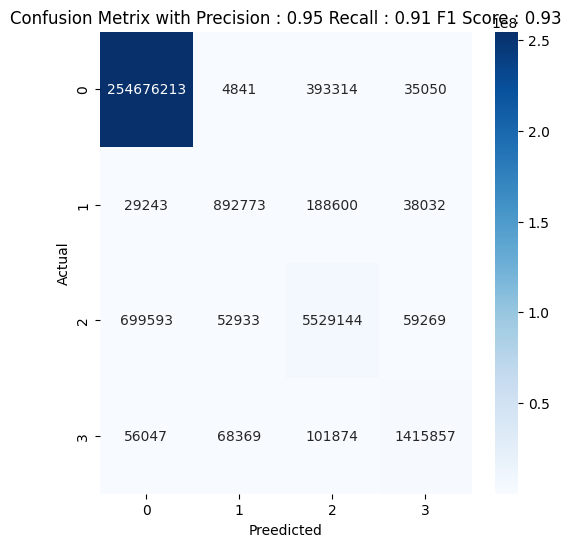

In [17]:
draw_confusionMetrix(torch.tensor(all_preds), torch.tensor(all_labels), num_classes=4)

In [18]:
torch.save(model, f'/content/drive/MyDrive/Brain_Project/model.pth')


In [21]:
import torch

# Example input shape (adjust to your model)
dummy_input = torch.randn(1, 4, 64, 64, 64).to(device)  # (batch, channels, H, W, D)

# Export
torch.onnx.export(
    model,
    dummy_input,
    "/content/drive/MyDrive/Brain_Project/segmentation_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=17,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}
)


/tmp/ipython-input-3768514932.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/tmp/ipython-input-2846506970.py:141: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[2:] != skip.shape[2:]:


In [20]:
%pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 110.3 MB/s eta 0:00:00
